
# Jet Tagging com Imagens (CNN) vs. Grafos/Nuvens de Partículas (GNN)

Este notebook é um projeto da eletiva "Aprendizado de Máquina" do Programa de Pós Graduação em Física da Universidade do Estado do Rio de Janeiro (UERJ) que implementa e compara duas abordagens clássicas de *jet tagging* em física de altas energias:

1. **CNN em "imagens de jato"** — cada jato é discretizado em um grid 2D (η × φ), com intensidade de pixel = pT depositado (análogo a uma imagem de calorímetro).
2. **GNN / Particle Cloud** — cada jato é tratado como uma nuvem de partículas (nós de um grafo), processada com uma arquitetura de atenção estilo **Particle Transformer** (uma versão leve, inspirada em ParticleNet/ParT).

Vamos rodar o **mesmo pipeline em duas tarefas físicas diferentes**:

- **Quark vs. Glúon** — dataset de Komiske, Metodiev & Thaler (usado no paper do ParticleNet), acessado via a biblioteca `energyflow` (É o sucessor "moderno" e mais acessível do dataset de imagens de Pierre Baldi et al. O dataset original de Baldi não tem mais um pacote de download direto mantido, então usamos a nuvem de partículas do EnergyFlow e a convertemos em imagem nós mesmos, o que é exatamente a mesma física.)
- **Top vs. QCD** — o *Top Tagging Reference Dataset* de Kasieczka, Plehn, Thompson & Russel (Zenodo, [doi:10.5281/zenodo.2603256](https://doi.org/10.5281/zenodo.2603256)).

Ao final, comparamos as duas abordagens em **AUC** e **rejeição de background a eficiência de sinal fixa**, e fazemos uma análise de **interpretabilidade** (saliency maps para a CNN, pesos de atenção para o Transformer).

> **Nota sobre desempenho**: este notebook foi desenhado para rodar em **CPU**, em um notebook/desktop comum, sem GPU. Por isso usamos sub-amostras dos datasets completos (que têm 1–2 milhões de jatos) e redes pequenas. Os hiperparâmetros de escala (`N_TRAIN`, `IMG_SIZE`, `MAX_PART`, épocas) estão centralizados na célula de configuração, se você tiver mais tempo/memória/GPU, é só aumentá-los.

---

## Estrutura do notebook

1. Setup e configuração
2. Dataset A: Quark vs. Glúon (`energyflow`)
3. Dataset B: Top vs. QCD (Zenodo)
4. Funções utilitárias de pré-processamento (comuns às duas tarefas)
5. Construção de imagens e de nuvens de partículas
6. Modelos: CNN (estilo ResNet) e Particle-Transformer (estilo GNN de atenção)
7. Treinamento
8. Avaliação: ROC, AUC, rejeição de background
9. Interpretabilidade: saliency maps (CNN) e pesos de atenção (Transformer)
10. Conclusões



## 1. Setup e configuração

Instalamos/importamos as bibliotecas necessárias. O pacote `energyflow` baixa automaticamente o dataset de quark/glúon na primeira execução (fica em cache em `~/.energyflow`). Para o Top Tagging, baixamos os arquivos `.h5` do Zenodo manualmente (são ~1.7 GB no total, então baixe apenas uma vez).


In [1]:
# Se necessário, descomente para instalar as dependências
!pip install torch numpy pandas scikit-learn matplotlib h5py tables energyflow 

In [54]:
# Necessario caso tenha algum erro na seção 4.2 ou posterior
!pip install --upgrade --force-reinstall --no-cache-dir "numpy<2" tables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 2.3 MB/s eta 0:00:000:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 2.4 MB/s eta 0:00:000:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 2.0 MB/s eta 0:00:00 MB/s eta 0:00:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 546.9/546.9 kB 975.3 kB/s eta 0:00:00m eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 638.2 kB/s eta 0:00:00 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 1.2 MB/s eta 0:00:001.2 MB/s eta 0:00:01
  Attempting uninstall: py-cpuinfo
    Found existing installation: py-cpuinfo 9.0.0
    Uninstalling py-cpuinfo-9.0.0:
      Successfully uninstalled py-cpuinfo-9.0.0
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.16.0
    Uninstalling typing_extensions-4.16.0:
      Successfully uninstalled typing_extensions-4.16.0
  Attempting uninstall: threadpoolctl
    Found existing i

In [3]:
import os
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_curve, auc

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", DEVICE)


Usando device: cpu


In [4]:

# CONFIGURAÇÃO CENTRAL DO PROJETO
# Ajuste estes valores conforme seu hardware. Os defaults abaixo rodam
# em poucos minutos em uma CPU comum.

class CFG:
    # --- dados ---
    N_TRAIN = 20000     # jatos de treino, por dataset (QG e Top)
    N_VAL   = 4000
    N_TEST  = 4000
    MAX_PART = 30        # nº máximo de constituentes usados por jato
    IMG_SIZE = 32         # resolução da imagem eta x phi
    ETA_RANGE = 0.8       # metade da largura da janela em eta (em torno do eixo do jato)
    PHI_RANGE = 0.8       # idem em phi

    # --- treino ---
    BATCH_SIZE = 256
    EPOCHS = 15
    LR = 1e-3
    PATIENCE = 4          # early stopping

    # --- caminhos ---
    DATA_DIR = "data"

os.makedirs(CFG.DATA_DIR, exist_ok=True)
print(vars(CFG))


{'__module__': '__main__', 'N_TRAIN': 20000, 'N_VAL': 4000, 'N_TEST': 4000, 'MAX_PART': 30, 'IMG_SIZE': 32, 'ETA_RANGE': 0.8, 'PHI_RANGE': 0.8, 'BATCH_SIZE': 256, 'EPOCHS': 15, 'LR': 0.001, 'PATIENCE': 4, 'DATA_DIR': 'data', '__dict__': <attribute '__dict__' of 'CFG' objects>, '__weakref__': <attribute '__weakref__' of 'CFG' objects>, '__doc__': None}



## 2. Funções utilitárias de pré-processamento

Ambos os datasets fornecem, para cada jato, uma lista de **constituentes** (partículas) com seus quadrimomentos — mas em parametrizações diferentes:

- Quark/Glúon (`energyflow`): cada partícula vem como `(pT, y, φ, pid)` — já em coordenadas de colisor.
- Top Tagging (Zenodo): cada partícula vem como `(E, px, py, pz)` — quadrimomento cartesiano.

Para tratar as duas tarefas com o **mesmo código de modelo**, convertemos tudo para uma representação comum:

- `pT`, `η`, `φ` de cada partícula;
- centralizamos no **eixo do jato** (a média ponderada por pT de η e φ dos constituentes), obtendo `Δη`, `Δφ` — isso é importante porque queremos uma representação *invariante à posição do jato no detector*;
- cuidamos do "wrap-around" de φ (periodicidade em 2π).

A partir de `(pT, Δη, Δφ)` conseguimos tanto:
- **pixelizar** em uma imagem 2D (para a CNN), quanto
- usar diretamente como **features dos nós** de uma nuvem de partículas (para o Transformer/GNN).


In [5]:
def to_pt_eta_phi_from_cartesian(px, py, pz):
    '''Converte (px,py,pz) -> (pt, eta, phi). Arrays de qualquer shape.'''
    pt = np.sqrt(px**2 + py**2)
    p  = np.sqrt(px**2 + py**2 + pz**2)
    # eta = arctanh(pz/p), com clip por segurança numérica
    ratio = np.clip(pz / np.clip(p, 1e-8, None), -0.999999, 0.999999)
    eta = np.arctanh(ratio)
    phi = np.arctan2(py, px)
    return pt, eta, phi


def wrap_phi(dphi):
    '''Traz a diferença de phi para o intervalo [-pi, pi].'''
    return (dphi + np.pi) % (2 * np.pi) - np.pi


def center_on_jet_axis(pt, eta, phi, mask):
    '''Recentraliza (eta,phi) de cada partícula em torno do eixo do jato
    (centroide ponderado por pT). pt/eta/phi/mask: (N_jets, N_part).
    Retorna deta, dphi com o mesmo shape.
    '''
    w = pt * mask
    wsum = w.sum(axis=1, keepdims=True) + 1e-8
    eta_axis = (w * eta).sum(axis=1, keepdims=True) / wsum
    # média vetorial em phi para lidar corretamente com a periodicidade
    phi_axis = np.arctan2(
        (w * np.sin(phi)).sum(axis=1, keepdims=True),
        (w * np.cos(phi)).sum(axis=1, keepdims=True),
    )
    deta = eta - eta_axis
    dphi = wrap_phi(phi - phi_axis)
    return deta, dphi


def sort_by_pt_desc(pt, *others):
    '''Ordena os constituentes de cada jato por pT decrescente (partículas
    reais primeiro, padding por último). others: outros arrays (N_jets,N_part)
    a serem reordenados junto.'''
    order = np.argsort(-pt, axis=1)
    pt_sorted = np.take_along_axis(pt, order, axis=1)
    others_sorted = [np.take_along_axis(o, order, axis=1) for o in others]
    return (pt_sorted, *others_sorted)


def truncate_or_pad(arr, max_len):
    '''Corta ou preenche com zeros a segunda dimensão (partículas) até max_len.'''
    n, p = arr.shape[0], arr.shape[1]
    if p >= max_len:
        return arr[:, :max_len]
    pad_width = [(0, 0), (0, max_len - p)] + [(0, 0)] * (arr.ndim - 2)
    return np.pad(arr, pad_width, mode="constant")


In [6]:
def jets_to_images(pt, deta, dphi, mask, img_size=CFG.IMG_SIZE,
                    eta_range=CFG.ETA_RANGE, phi_range=CFG.PHI_RANGE):
    '''Constrói imagens eta x phi (histograma 2D ponderado por pT) para um
    lote de jatos. pt/deta/dphi/mask: (N_jets, N_part). Retorna array
    (N_jets, 1, img_size, img_size).
    '''
    bins_eta = np.linspace(-eta_range, eta_range, img_size + 1)
    bins_phi = np.linspace(-phi_range, phi_range, img_size + 1)
    n_jets = pt.shape[0]
    images = np.zeros((n_jets, img_size, img_size), dtype=np.float32)
    for i in range(n_jets):
        valid = mask[i] > 0
        if valid.sum() == 0:
            continue
        img, _, _ = np.histogram2d(
            deta[i, valid], dphi[i, valid],
            bins=[bins_eta, bins_phi], weights=pt[i, valid],
        )
        images[i] = img
    return images[:, None, :, :]  # canal único


def build_particle_cloud(pt, deta, dphi, e_or_none, mask):
    '''Monta o tensor de features dos nós para o modelo tipo GNN/Transformer.
    Features por partícula: [log(pT+1), deta, dphi, log(pT_rel+1)]
    (log(E) é incluído quando disponível).
    Retorna array (N_jets, N_part, n_features).
    '''
    pt_jet = (pt * mask).sum(axis=1, keepdims=True) + 1e-8
    pt_rel = (pt / pt_jet) * mask
    log_pt = np.log(pt * mask + 1.0)
    feats = [log_pt, deta * mask, dphi * mask, np.log(pt_rel + 1.0) * mask]
    if e_or_none is not None:
        feats.append(np.log(e_or_none * mask + 1.0))
    cloud = np.stack(feats, axis=-1)
    cloud[mask == 0] = 0.0
    return cloud.astype(np.float32)



## 3. Dataset A — Quark vs. Glúon

Usamos o dataset público de Komiske, Metodiev & Thaler (2019), disponibilizado pelo pacote [`energyflow`](https://energyflow.network/docs/datasets/). Ele contém 2 milhões de jatos simulados com Pythia 8, rotulados como **quark (1)** ou **glúon (0)**, cada um com até ~150 constituentes na forma `(pT, y, φ, PDG-id)`.

O pacote baixa automaticamente (e faz cache) os arquivos necessários na primeira chamada.


In [7]:
import energyflow as ef

N_QG_TOTAL = CFG.N_TRAIN + CFG.N_VAL + CFG.N_TEST
print(f"Carregando {N_QG_TOTAL} jatos quark/gluon via energyflow (pode baixar dados na 1a vez)...")

X_qg, y_qg = ef.qg_jets.load(num_data=N_QG_TOTAL, pad=True, ncol=4, generator="pythia",
                              cache_dir=os.path.join(CFG.DATA_DIR, "energyflow_cache"))
# X_qg: (N, max_part, 4) colunas = (pt, y, phi, pid) | y_qg: 1=quark, 0=gluon
print("X_qg shape:", X_qg.shape, " y_qg shape:", y_qg.shape)
print("Fração de quarks:", y_qg.mean())


Carregando 28000 jatos quark/gluon via energyflow (pode baixar dados na 1a vez)...
X_qg shape: (28000, 139, 4)  y_qg shape: (28000,)
Fração de quarks: 0.5021785714285715


In [8]:
def prepare_qg(X, y, max_part=CFG.MAX_PART):
    pt, eta, phi = X[:, :, 0], X[:, :, 1], X[:, :, 2]
    mask = (pt > 0).astype(np.float32)
    pt, eta, phi, mask = sort_by_pt_desc(pt, eta, phi, mask)
    pt = truncate_or_pad(pt, max_part)
    eta = truncate_or_pad(eta, max_part)
    phi = truncate_or_pad(phi, max_part)
    mask = truncate_or_pad(mask, max_part)
    deta, dphi = center_on_jet_axis(pt, eta, phi, mask)
    return pt.astype(np.float32), deta.astype(np.float32), dphi.astype(np.float32), mask.astype(np.float32)

pt_qg, deta_qg, dphi_qg, mask_qg = prepare_qg(X_qg, y_qg)

images_qg = jets_to_images(pt_qg, deta_qg, dphi_qg, mask_qg)
clouds_qg = build_particle_cloud(pt_qg, deta_qg, dphi_qg, None, mask_qg)
labels_qg = y_qg.astype(np.float32)

print("images_qg:", images_qg.shape, " clouds_qg:", clouds_qg.shape)

# split train/val/test (mesma ordem em que foram carregados; o dataset já vem embaralhado)
n_tr, n_va = CFG.N_TRAIN, CFG.N_VAL
qg_split = {
    "train": (images_qg[:n_tr], clouds_qg[:n_tr], mask_qg[:n_tr], labels_qg[:n_tr]),
    "val":   (images_qg[n_tr:n_tr+n_va], clouds_qg[n_tr:n_tr+n_va], mask_qg[n_tr:n_tr+n_va], labels_qg[n_tr:n_tr+n_va]),
    "test":  (images_qg[n_tr+n_va:], clouds_qg[n_tr+n_va:], mask_qg[n_tr+n_va:], labels_qg[n_tr+n_va:]),
}
for k, v in qg_split.items():
    print(k, [a.shape for a in v])


images_qg: (28000, 1, 32, 32)  clouds_qg: (28000, 30, 4)
train [(20000, 1, 32, 32), (20000, 30, 4), (20000, 30), (20000,)]
val [(4000, 1, 32, 32), (4000, 30, 4), (4000, 30), (4000,)]
test [(4000, 1, 32, 32), (4000, 30, 4), (4000, 30), (4000,)]


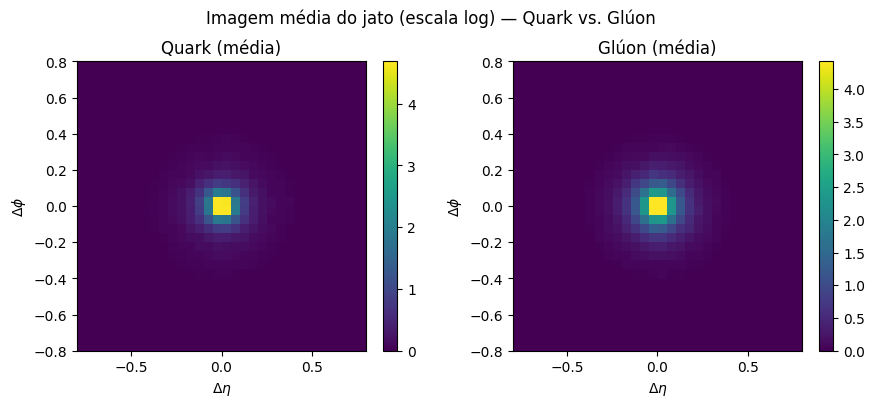

In [9]:
# Visualização: imagem média (quark vs gluon) - ajuda a inspecionar a
# qualidade do pré-processamento (o jato deve ficar centralizado)
imgs_tr, _, _, lab_tr = qg_split["train"]
avg_quark = imgs_tr[lab_tr == 1].mean(axis=0)[0]
avg_gluon = imgs_tr[lab_tr == 0].mean(axis=0)[0]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, img, title in zip(axes, [avg_quark, avg_gluon], ["Quark (média)", "Glúon (média)"]):
    im = ax.imshow(np.log1p(img).T, origin="lower", cmap="viridis",
                    extent=[-CFG.ETA_RANGE, CFG.ETA_RANGE, -CFG.PHI_RANGE, CFG.PHI_RANGE])
    ax.set_title(title); ax.set_xlabel(r"$\Delta\eta$"); ax.set_ylabel(r"$\Delta\phi$")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Imagem média do jato (escala log) — Quark vs. Glúon")
plt.tight_layout(); plt.show()



## 4. Dataset B — Top vs. QCD (Top Tagging Reference Dataset)

Dataset de Kasieczka, Plehn, Thompson & Russel — [Zenodo, doi:10.5281/zenodo.2603256](https://doi.org/10.5281/zenodo.2603256). Contém 1.2M jatos de treino + 400k de validação + 400k de teste, rotulados como **top (1)** ou **QCD (0)**, com até 200 constituentes por jato na forma `(E, px, py, pz)`, já ordenados por pT decrescente.

### 4.1 Download

Os arquivos são grandes (~1.7 GB no total). Baixe uma vez; nas próximas execuções o código pula o download se o arquivo já existir.


In [10]:
import urllib.request

ZENODO_BASE = "https://zenodo.org/records/2603256/files"
TOP_FILES = {
    "train": "train.h5",
    "val":   "val.h5",
    "test":  "test.h5",
}

def download_if_needed(fname):
    path = os.path.join(CFG.DATA_DIR, fname)
    if os.path.exists(path):
        print(f"{fname} já existe, pulando download.")
        return path
    url = f"{ZENODO_BASE}/{fname}?download=1"
    print(f"Baixando {fname} de {url} ... (pode demorar alguns minutos)")
    urllib.request.urlretrieve(url, path)
    print(f"{fname} baixado com sucesso.")
    return path

# Descomente a linha abaixo para baixar de fato e Comente se já tiver os arquivos baixados (arquivos grandes!):
top_paths = {k: download_if_needed(v) for k, v in TOP_FILES.items()}
top_paths = {k: os.path.join(CFG.DATA_DIR, v) for k, v in TOP_FILES.items()}


Baixando train.h5 de https://zenodo.org/records/2603256/files/train.h5?download=1 ... (pode demorar alguns minutos)
train.h5 baixado com sucesso.
Baixando val.h5 de https://zenodo.org/records/2603256/files/val.h5?download=1 ... (pode demorar alguns minutos)
val.h5 baixado com sucesso.
Baixando test.h5 de https://zenodo.org/records/2603256/files/test.h5?download=1 ... (pode demorar alguns minutos)
test.h5 baixado com sucesso.



### 4.2 Leitura parcial (sem estourar a memória)

Os arquivos `.h5` foram salvos com `pandas.HDFStore` no formato `table`, então conseguimos ler **apenas as primeiras N linhas** de cada arquivo sem carregar o `.h5` inteiro na RAM, importante para rodar em uma máquina com pouco processamento.


In [11]:
def load_top_partial(path, n_rows, max_part=CFG.MAX_PART):
    '''Lê as primeiras n_rows linhas de um arquivo do Top Tagging dataset e
    retorna pt, eta, phi, mask, label já convertidos.'''
    df = pd.read_hdf(path, key="table", start=0, stop=n_rows)

    n = len(df)
    e_cols  = [f"E_{i}"  for i in range(max_part)]
    px_cols = [f"PX_{i}" for i in range(max_part)]
    py_cols = [f"PY_{i}" for i in range(max_part)]
    pz_cols = [f"PZ_{i}" for i in range(max_part)]

    E  = df[e_cols].to_numpy(dtype=np.float32)
    px = df[px_cols].to_numpy(dtype=np.float32)
    py = df[py_cols].to_numpy(dtype=np.float32)
    pz = df[pz_cols].to_numpy(dtype=np.float32)
    y  = df["is_signal_new"].to_numpy(dtype=np.float32)

    pt, eta, phi = to_pt_eta_phi_from_cartesian(px, py, pz)
    mask = (E > 0).astype(np.float32)
    pt = pt * mask
    deta, dphi = center_on_jet_axis(pt, eta, phi, mask)
    return pt, deta, dphi, E * mask, mask, y


# ATENÇÃO: isso assume que os arquivos já foram baixados na célula anterior.
# Aqui só demonstramos a chamada:
try:
    pt_top_tr, deta_top_tr, dphi_top_tr, e_top_tr, mask_top_tr, y_top_tr = load_top_partial(
        top_paths["train"], CFG.N_TRAIN)
    pt_top_va, deta_top_va, dphi_top_va, e_top_va, mask_top_va, y_top_va = load_top_partial(
        top_paths["val"], CFG.N_VAL)
    pt_top_te, deta_top_te, dphi_top_te, e_top_te, mask_top_te, y_top_te = load_top_partial(
        top_paths["test"], CFG.N_TEST)
    print("Top train:", pt_top_tr.shape, " frac. top:", y_top_tr.mean())
except FileNotFoundError:
    print("Arquivos do Top Tagging ainda não baixados — rode a célula de download acima primeiro.")


Top train: (20000, 30)  frac. top: 0.5035


In [12]:
def images_and_clouds_from_top(pt, deta, dphi, e, mask, y):
    images = jets_to_images(pt, deta, dphi, mask)
    clouds = build_particle_cloud(pt, deta, dphi, e, mask)
    return images, clouds, mask, y.astype(np.float32)

top_split = {}
for name, (pt_, deta_, dphi_, e_, mask_, y_) in [
    ("train", (pt_top_tr, deta_top_tr, dphi_top_tr, e_top_tr, mask_top_tr, y_top_tr)),
    ("val",   (pt_top_va, deta_top_va, dphi_top_va, e_top_va, mask_top_va, y_top_va)),
    ("test",  (pt_top_te, deta_top_te, dphi_top_te, e_top_te, mask_top_te, y_top_te)),
]:
    top_split[name] = images_and_clouds_from_top(pt_, deta_, dphi_, e_, mask_, y_)
    print(name, [a.shape if hasattr(a, "shape") else a for a in top_split[name]])


train [(20000, 1, 32, 32), (20000, 30, 5), (20000, 30), (20000,)]
val [(4000, 1, 32, 32), (4000, 30, 5), (4000, 30), (4000,)]
test [(4000, 1, 32, 32), (4000, 30, 5), (4000, 30), (4000,)]


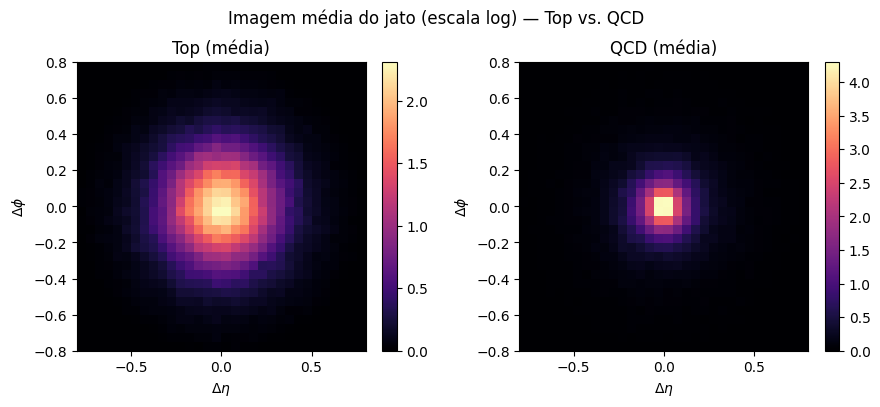

In [13]:
imgs_tr_top, _, _, lab_tr_top = top_split["train"]
avg_top = imgs_tr_top[lab_tr_top == 1].mean(axis=0)[0]
avg_qcd = imgs_tr_top[lab_tr_top == 0].mean(axis=0)[0]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, img, title in zip(axes, [avg_top, avg_qcd], ["Top (média)", "QCD (média)"]):
    im = ax.imshow(np.log1p(img).T, origin="lower", cmap="magma",
                    extent=[-CFG.ETA_RANGE, CFG.ETA_RANGE, -CFG.PHI_RANGE, CFG.PHI_RANGE])
    ax.set_title(title); ax.set_xlabel(r"$\Delta\eta$"); ax.set_ylabel(r"$\Delta\phi$")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Imagem média do jato (escala log) — Top vs. QCD")
plt.tight_layout(); plt.show()



Repare a diferença física esperada: jatos de **top** tendem a mostrar **subestrutura de 3 lóbulos/prongs** (do decaimento $t \to bqq'$), enquanto jatos de **QCD** e de **glúon** tendem a ser mais difusos e simétricos em torno do eixo, e jatos de **quark** costumam ser mais colimados (mais estreitos) que os de glúon.



## 5. Modelos

### 5.1 CNN (abordagem "imagem")

Uma pequena **ResNet**: um stem convolucional, dois blocos residuais (com uma redução de resolução no meio) e uma cabeça de classificação. É deliberadamente pequena para treinar rápido em CPU (a máquina usada para esse projeto), mas mantém os ingredientes centrais (conv + batchnorm + skip connections) de uma ResNet de verdade.

### 5.2 GNN / Particle-Transformer (abordagem "nuvem de partículas")

Implementamos aqui uma versão **leve do Particle Transformer**: cada partícula é um "nó"/token, e usamos **self-attention multi-cabeça** para que cada partícula "converse" com todas as outras do jato, isso é uma generalização das arquiteturas de grafo (é equivalente a um grafo *completamente conectado* com pesos de aresta aprendidos = os pesos de atenção). Escolhemos essa arquitetura em vez do EdgeConv/k-NN do ParticleNet por dois motivos práticos:

1. É mais leve em CPU (não precisa recalcular vizinhos-mais-próximos a cada camada).
2. Os **pesos de atenção** nos dão diretamente um mecanismo de interpretabilidade (Seção 9).

Usamos um **token de classe (`[CLS]`)** que agrega informação de todas as partículas via atenção, similar ao usado em Transformers de linguagem/visão, e do qual extraímos os logits finais.


In [14]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(ch)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(ch)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + x)


class JetCNN(nn.Module):
    '''Pequena ResNet para classificar imagens de jato (1 canal, IMG_SIZE x IMG_SIZE).'''
    def __init__(self, in_ch=1, base=16):
        super().__init__()
        self.stem = nn.Conv2d(in_ch, base, 3, padding=1)
        self.bn_stem = nn.BatchNorm2d(base)
        self.block1 = ResBlock(base)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(base, base * 2, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(base * 2)
        self.block2 = ResBlock(base * 2)
        self.pool2 = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(base * 2, 1)

    def forward(self, x):
        x = F.relu(self.bn_stem(self.stem(x)))
        x = self.block1(x)
        x = self.pool1(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.block2(x)
        x = self.pool2(x).flatten(1)
        return self.fc(x).squeeze(-1)  # logit


In [15]:
class ParticleTransformerLite(nn.Module):
    '''Versão leve do Particle Transformer: self-attention multi-cabeça
    sobre a nuvem de partículas + token [CLS] para classificação.
    in_dim: nº de features por partícula (ver build_particle_cloud).
    '''
    def __init__(self, in_dim, d_model=32, n_heads=4, n_layers=2, ff_dim=64, dropout=0.1):
        super().__init__()
        self.embed = nn.Sequential(nn.Linear(in_dim, d_model), nn.ReLU())
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x, mask):
        # x: (B, N, in_dim), mask: (B, N) com 1=particula real, 0=padding
        B = x.shape[0]
        h = self.embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        h = torch.cat([cls, h], dim=1)                       # (B, N+1, d_model)
        pad_mask = torch.cat(
            [torch.zeros(B, 1, device=x.device), (mask == 0).float()], dim=1
        ).bool()                                             # True = ignorar
        h = self.encoder(h, src_key_padding_mask=pad_mask)
        logit = self.fc(h[:, 0]).squeeze(-1)                 # usa o token [CLS]
        return logit

    def get_cls_attention(self, x, mask, layer_idx=0):
        '''Retorna os pesos de atenção do token [CLS] para cada partícula,
        extraídos da camada `layer_idx` do encoder (usado na Seção 9).'''
        attn_store = {}
        target_layer = self.encoder.layers[layer_idx].self_attn
        orig_forward = target_layer.forward

        def wrapped(*args, **kwargs):
            kwargs["need_weights"] = True
            kwargs["average_attn_weights"] = True
            out = orig_forward(*args, **kwargs)
            attn_store["w"] = out[1].detach()
            return out

        target_layer.forward = wrapped
        # o PyTorch usa um "fast path" (nested tensors) quando percebe que os
        # pesos de atencao nao serao usados, o que ignora nosso monkey-patch
        # acima. Desativamos esse fast path temporariamente para garantir que
        # o forward "de verdade" (que calcula os pesos) seja executado.
        fastpath_supported = hasattr(torch.backends, "mha")
        if fastpath_supported:
            was_enabled = torch.backends.mha.get_fastpath_enabled()
            torch.backends.mha.set_fastpath_enabled(False)
        try:
            with torch.no_grad():
                self.forward(x, mask)
        finally:
            target_layer.forward = orig_forward
            if fastpath_supported:
                torch.backends.mha.set_fastpath_enabled(was_enabled)
        # attn_store["w"]: (B, N+1, N+1) -> pegamos a linha do [CLS] (índice 0)
        # para as demais partículas (índices 1:)
        return attn_store["w"][:, 0, 1:]



## 6. `Dataset`/`DataLoader` e função de treino genérica

Criamos wrappers simples de `torch.utils.data.Dataset` para as duas representações (imagem e nuvem de partículas), e uma função de treino genérica (usada para todos os 4 experimentos: {CNN, Transformer} × {Quark/Glúon, Top/QCD}), com **early stopping** baseado na perda de validação.


In [16]:
class JetImageDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.from_numpy(images).float()
        self.labels = torch.from_numpy(labels).float()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


class JetCloudDataset(Dataset):
    def __init__(self, clouds, mask, labels):
        self.clouds = torch.from_numpy(clouds).float()
        self.mask = torch.from_numpy(mask).float()
        self.labels = torch.from_numpy(labels).float()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.clouds[idx], self.mask[idx], self.labels[idx]


In [17]:
def train_model(model, train_loader, val_loader, epochs=CFG.EPOCHS, lr=CFG.LR,
                 patience=CFG.PATIENCE, is_cloud_model=False, verbose=True):
    '''Loop de treino genérico com early stopping. Funciona tanto para a CNN
    (batches = (imagens, labels)) quanto para o Transformer
    (batches = (nuvem, mask, labels)), via a flag is_cloud_model.'''
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=2)

    best_val = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for batch in train_loader:
            opt.zero_grad()
            if is_cloud_model:
                x, m, y = [t.to(DEVICE) for t in batch]
                logits = model(x, m)
            else:
                x, y = [t.to(DEVICE) for t in batch]
                logits = model(x)
            loss = F.binary_cross_entropy_with_logits(logits, y)
            loss.backward()
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch in val_loader:
                if is_cloud_model:
                    x, m, y = [t.to(DEVICE) for t in batch]
                    logits = model(x, m)
                else:
                    x, y = [t.to(DEVICE) for t in batch]
                    logits = model(x)
                loss = F.binary_cross_entropy_with_logits(logits, y)
                val_losses.append(loss.item())

        tr_loss, va_loss = np.mean(train_losses), np.mean(val_losses)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        sched.step(va_loss)
        if verbose:
            print(f"epoch {epoch+1:02d}/{epochs} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f}")

        if va_loss < best_val - 1e-5:
            best_val = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping na época {epoch+1} (sem melhora por {patience} épocas).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history



## 7. Rodando os experimentos

Vamos treinar **4 modelos**:

| | Quark vs. Glúon | Top vs. QCD |
|---|---|---|
| **CNN (imagem)** | `cnn_qg` | `cnn_top` |
| **Transformer (nuvem)** | `part_qg` | `part_top` |

Cada um usa a mesma função `train_model` da Seção 6. Em CPU, com os hiperparâmetros default (20k jatos de treino, redes pequenas), cada treino leva tipicamente alguns minutos.


In [18]:
def make_loaders_images(split_dict, batch_size=CFG.BATCH_SIZE):
    loaders = {}
    for name, (images, clouds, mask, labels) in split_dict.items():
        ds = JetImageDataset(images, labels)
        loaders[name] = DataLoader(ds, batch_size=batch_size, shuffle=(name == "train"))
    return loaders


def make_loaders_clouds(split_dict, batch_size=CFG.BATCH_SIZE):
    loaders = {}
    for name, (images, clouds, mask, labels) in split_dict.items():
        ds = JetCloudDataset(clouds, mask, labels)
        loaders[name] = DataLoader(ds, batch_size=batch_size, shuffle=(name == "train"))
    return loaders


img_loaders_qg = make_loaders_images(qg_split)
cloud_loaders_qg = make_loaders_clouds(qg_split)
img_loaders_top = make_loaders_images(top_split)
cloud_loaders_top = make_loaders_clouds(top_split)


In [19]:
print("=== Treinando CNN em Quark vs. Glúon ===")
cnn_qg = JetCNN()
cnn_qg, hist_cnn_qg = train_model(cnn_qg, img_loaders_qg["train"], img_loaders_qg["val"],
                                   is_cloud_model=False)


=== Treinando CNN em Quark vs. Glúon ===
epoch 01/15 | train_loss=0.5752 | val_loss=0.9980
epoch 02/15 | train_loss=0.5206 | val_loss=2.0291
epoch 03/15 | train_loss=0.5121 | val_loss=1.4368
epoch 04/15 | train_loss=0.5068 | val_loss=1.1215
epoch 05/15 | train_loss=0.4986 | val_loss=1.2948
Early stopping na época 5 (sem melhora por 4 épocas).


In [20]:
print("=== Treinando Particle-Transformer em Quark vs. Glúon ===")
n_feat_qg = clouds_qg.shape[-1]
part_qg = ParticleTransformerLite(in_dim=n_feat_qg)
part_qg, hist_part_qg = train_model(part_qg, cloud_loaders_qg["train"], cloud_loaders_qg["val"],
                                     is_cloud_model=True)


=== Treinando Particle-Transformer em Quark vs. Glúon ===


/home/levi/miniconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:177.)
  output = torch._nested_tensor_from_mask(


epoch 01/15 | train_loss=0.5498 | val_loss=0.5027
epoch 02/15 | train_loss=0.5173 | val_loss=0.5030
epoch 03/15 | train_loss=0.5118 | val_loss=0.5006
epoch 04/15 | train_loss=0.5149 | val_loss=0.5020
epoch 05/15 | train_loss=0.5100 | val_loss=0.4967
epoch 06/15 | train_loss=0.5078 | val_loss=0.4982
epoch 07/15 | train_loss=0.5033 | val_loss=0.4971
epoch 08/15 | train_loss=0.4999 | val_loss=0.4870
epoch 09/15 | train_loss=0.4997 | val_loss=0.4871
epoch 10/15 | train_loss=0.4974 | val_loss=0.4851
epoch 11/15 | train_loss=0.4987 | val_loss=0.4845
epoch 12/15 | train_loss=0.4952 | val_loss=0.4911
epoch 13/15 | train_loss=0.4963 | val_loss=0.4839
epoch 14/15 | train_loss=0.4933 | val_loss=0.4863
epoch 15/15 | train_loss=0.4898 | val_loss=0.4788


In [21]:
print("=== Treinando CNN em Top vs. QCD ===")
cnn_top = JetCNN()
cnn_top, hist_cnn_top = train_model(cnn_top, img_loaders_top["train"], img_loaders_top["val"],
                                     is_cloud_model=False)


=== Treinando CNN em Top vs. QCD ===
epoch 01/15 | train_loss=0.3813 | val_loss=0.3740
epoch 02/15 | train_loss=0.2704 | val_loss=0.3050
epoch 03/15 | train_loss=0.2482 | val_loss=0.4184
epoch 04/15 | train_loss=0.2372 | val_loss=0.2328
epoch 05/15 | train_loss=0.2298 | val_loss=0.2292
epoch 06/15 | train_loss=0.2234 | val_loss=0.3675
epoch 07/15 | train_loss=0.2211 | val_loss=0.4641
epoch 08/15 | train_loss=0.2151 | val_loss=0.7982
epoch 09/15 | train_loss=0.2097 | val_loss=0.2372
Early stopping na época 9 (sem melhora por 4 épocas).


In [22]:
print("=== Treinando Particle-Transformer em Top vs. QCD ===")
n_feat_top = top_split["train"][1].shape[-1]
part_top = ParticleTransformerLite(in_dim=n_feat_top)
part_top, hist_part_top = train_model(part_top, cloud_loaders_top["train"], cloud_loaders_top["val"],
                                       is_cloud_model=True)


=== Treinando Particle-Transformer em Top vs. QCD ===
epoch 01/15 | train_loss=0.6144 | val_loss=0.5603
epoch 02/15 | train_loss=0.5543 | val_loss=0.5304
epoch 03/15 | train_loss=0.5152 | val_loss=0.4759
epoch 04/15 | train_loss=0.4391 | val_loss=0.4149
epoch 05/15 | train_loss=0.3914 | val_loss=0.3490
epoch 06/15 | train_loss=0.3528 | val_loss=0.3062
epoch 07/15 | train_loss=0.3332 | val_loss=0.4400
epoch 08/15 | train_loss=0.3379 | val_loss=0.2975
epoch 09/15 | train_loss=0.3015 | val_loss=0.2768
epoch 10/15 | train_loss=0.2921 | val_loss=0.2799
epoch 11/15 | train_loss=0.2893 | val_loss=0.2693
epoch 12/15 | train_loss=0.2846 | val_loss=0.2707
epoch 13/15 | train_loss=0.2864 | val_loss=0.2687
epoch 14/15 | train_loss=0.2857 | val_loss=0.2670
epoch 15/15 | train_loss=0.2862 | val_loss=0.2697


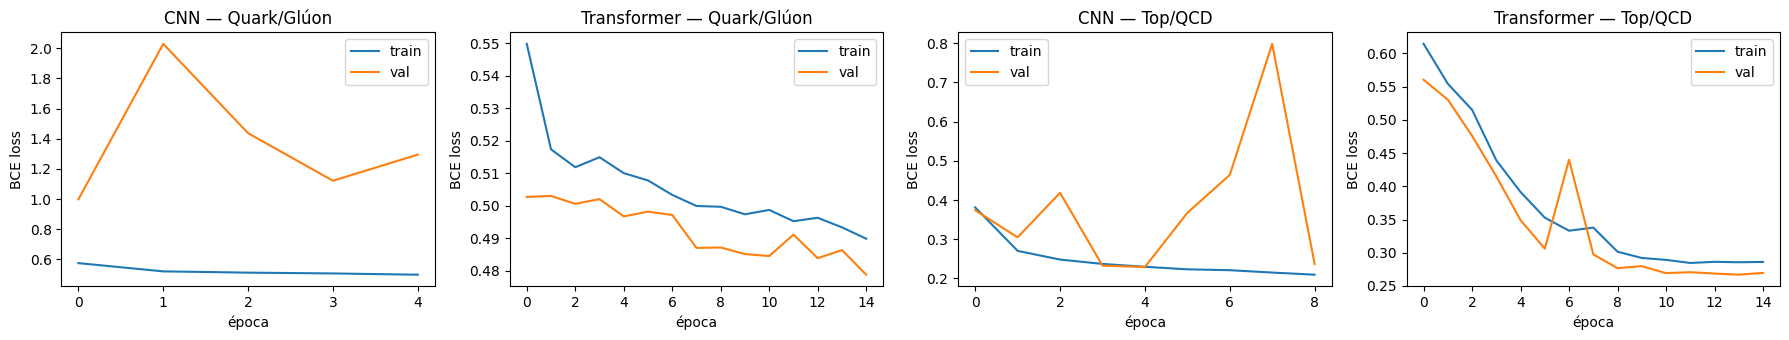

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
for ax, (title, hist) in zip(axes, [
    ("CNN — Quark/Glúon", hist_cnn_qg),
    ("Transformer — Quark/Glúon", hist_part_qg),
    ("CNN — Top/QCD", hist_cnn_top),
    ("Transformer — Top/QCD", hist_part_top),
]):
    ax.plot(hist["train_loss"], label="train")
    ax.plot(hist["val_loss"], label="val")
    ax.set_title(title); ax.set_xlabel("época"); ax.set_ylabel("BCE loss"); ax.legend()
plt.tight_layout(); plt.show()



## 8. Avaliação: ROC, AUC e rejeição de background

A métrica padrão da área não é só a AUC, mas principalmente a **rejeição de background a uma eficiência de sinal fixa**: $1 / \epsilon_B$ no ponto da curva ROC onde $\epsilon_S$ (eficiência de sinal / true positive rate) atinge um valor de referência — tipicamente **30%** ou **50%**. Isso reflete o cenário real de uso: um "tagger" é operado em um ponto de corte fixo, e o que importa é o quanto ele rejeita background naquele ponto (não a AUC "média" sobre todos os pontos de operação).


In [24]:
@torch.no_grad()
def get_scores(model, loader, is_cloud_model):
    model.eval()
    all_scores, all_labels = [], []
    for batch in loader:
        if is_cloud_model:
            x, m, y = batch
            logits = model(x.to(DEVICE), m.to(DEVICE))
        else:
            x, y = batch
            logits = model(x.to(DEVICE))
        scores = torch.sigmoid(logits).cpu().numpy()
        all_scores.append(scores)
        all_labels.append(y.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)


def bkg_rejection_at_sig_eff(y_true, y_score, target_eff=0.3):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    # interpola o menor fpr tal que tpr >= target_eff
    idx = np.searchsorted(tpr, target_eff)
    idx = min(idx, len(fpr) - 1)
    fpr_at_eff = max(fpr[idx], 1e-12)
    return 1.0 / fpr_at_eff


def evaluate(model, loader, is_cloud_model, name):
    y_score, y_true = get_scores(model, loader, is_cloud_model)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_val = auc(fpr, tpr)
    rej_30 = bkg_rejection_at_sig_eff(y_true, y_score, 0.3)
    rej_50 = bkg_rejection_at_sig_eff(y_true, y_score, 0.5)
    print(f"{name:28s} | AUC={auc_val:.4f} | 1/eps_B @ eps_S=0.3: {rej_30:8.1f} | @ eps_S=0.5: {rej_50:8.1f}")
    return {"name": name, "fpr": fpr, "tpr": tpr, "auc": auc_val, "rej_30": rej_30, "rej_50": rej_50}


In [25]:
results = []
results.append(evaluate(cnn_qg, img_loaders_qg["test"], False, "CNN (Quark/Glúon)"))
results.append(evaluate(part_qg, cloud_loaders_qg["test"], True, "Transformer (Quark/Glúon)"))
results.append(evaluate(cnn_top, img_loaders_top["test"], False, "CNN (Top/QCD)"))
results.append(evaluate(part_top, cloud_loaders_top["test"], True, "Transformer (Top/QCD)"))

results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ("fpr", "tpr")} for r in results])
results_df


CNN (Quark/Glúon)            | AUC=0.8070 | 1/eps_B @ eps_S=0.3:     33.0 | @ eps_S=0.5:     12.6
Transformer (Quark/Glúon)    | AUC=0.8392 | 1/eps_B @ eps_S=0.3:     58.5 | @ eps_S=0.5:     18.3
CNN (Top/QCD)                | AUC=0.9689 | 1/eps_B @ eps_S=0.3:    101.0 | @ eps_S=0.5:     62.4
Transformer (Top/QCD)        | AUC=0.9373 | 1/eps_B @ eps_S=0.3:     43.3 | @ eps_S=0.5:     20.6


,name,auc,rej_30,rej_50
0,CNN (Quark/Glúon),0.806975,33.016129,12.635802
1,Transformer (Quark/Glúon),0.839199,58.485714,18.276786
2,CNN (Top/QCD),0.968873,100.952381,62.352941
3,Transformer (Top/QCD),0.937349,43.265306,20.582524


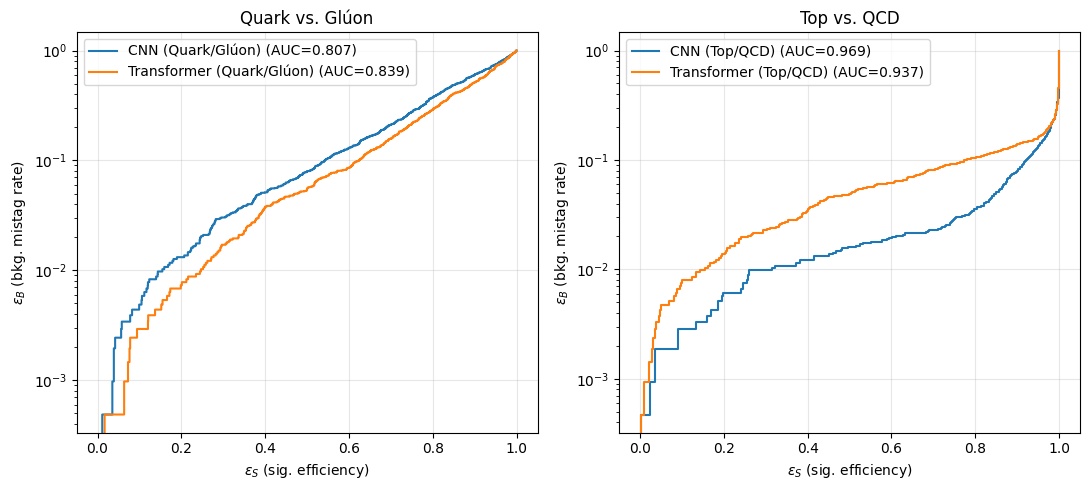

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# painel esquerdo: Quark vs Glúon
for r in results:
    if "Quark" in r["name"]:
        axes[0].plot(r["tpr"], r["fpr"], label=f'{r["name"]} (AUC={r["auc"]:.3f})')
axes[0].set_yscale("log"); axes[0].set_xlabel(r"$\epsilon_S$ (sig. efficiency)")
axes[0].set_ylabel(r"$\epsilon_B$ (bkg. mistag rate)"); axes[0].set_title("Quark vs. Glúon")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# painel direito: Top vs QCD
for r in results:
    if "Top" in r["name"]:
        axes[1].plot(r["tpr"], r["fpr"], label=f'{r["name"]} (AUC={r["auc"]:.3f})')
axes[1].set_yscale("log"); axes[1].set_xlabel(r"$\epsilon_S$ (sig. efficiency)")
axes[1].set_ylabel(r"$\epsilon_B$ (bkg. mistag rate)"); axes[1].set_title("Top vs. QCD")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()



De modo geral, na literatura (com datasets completos e redes bem maiores/treinadas por mais tempo), o Particle Transformer supera a CNN baseada em imagem, principalmente porque (i) não perde informação por causa da discretização em pixels, (ii) lida naturalmente com o número variável de constituentes, e (iii) usa toda a informação disponível por partícula (não só a energia depositada em uma célula). Com os hiperparâmetros reduzidos deste notebook (poucos milhares de jatos, redes pequenas, poucas épocas) essa vantagem pode ser mais modesta, se quiser reproduzir os números de referência da literatura, aumente `N_TRAIN`, `EPOCHS` e o tamanho das redes (idealmente com GPU).



## 9. Interpretabilidade

### 9.1 Saliency maps (CNN)

Calculamos o **gradiente do score de saída em relação a cada pixel de entrada** (`vanilla gradient saliency`): pixels com gradiente de magnitude alta são aqueles que, se alterados, mais mudariam a decisão do modelo. Funcionam como um mapa de "onde a rede está olhando".

### 9.2 Pesos de atenção (Particle-Transformer)

Para o modelo baseado em atenção, extraímos os **pesos de atenção do token `[CLS]`** (que gera a decisão final) em relação a cada partícula da nuvem, isso nos diz diretamente quais partículas mais influenciaram a classificação, sem precisar de gradientes.


In [27]:
def compute_saliency(model, image_tensor):
    model.eval()
    img = image_tensor.clone().unsqueeze(0).to(DEVICE).requires_grad_(True)
    score = model(img)
    score.backward()
    saliency = img.grad.abs().squeeze().cpu().numpy()
    return saliency, torch.sigmoid(score).item()


def plot_saliency_examples(model, dataset, labels, class_names, n_examples=3, eta_r=CFG.ETA_RANGE, phi_r=CFG.PHI_RANGE):
    fig, axes = plt.subplots(n_examples, 2, figsize=(7, 3 * n_examples))
    idxs = np.random.choice(len(labels), n_examples, replace=False)
    for row, idx in enumerate(idxs):
        img_tensor, y = dataset[idx]
        saliency, score = compute_saliency(model, img_tensor)
        extent = [-eta_r, eta_r, -phi_r, phi_r]
        axes[row, 0].imshow(np.log1p(img_tensor.squeeze().numpy()).T, origin="lower", cmap="viridis", extent=extent)
        axes[row, 0].set_title(f"Imagem (label={class_names[int(y)]})")
        axes[row, 1].imshow(saliency.T, origin="lower", cmap="inferno", extent=extent)
        axes[row, 1].set_title(f"Saliency (score modelo={score:.2f})")
        for a in axes[row]:
            a.set_xlabel(r"$\Delta\eta$"); a.set_ylabel(r"$\Delta\phi$")
    plt.tight_layout(); plt.show()


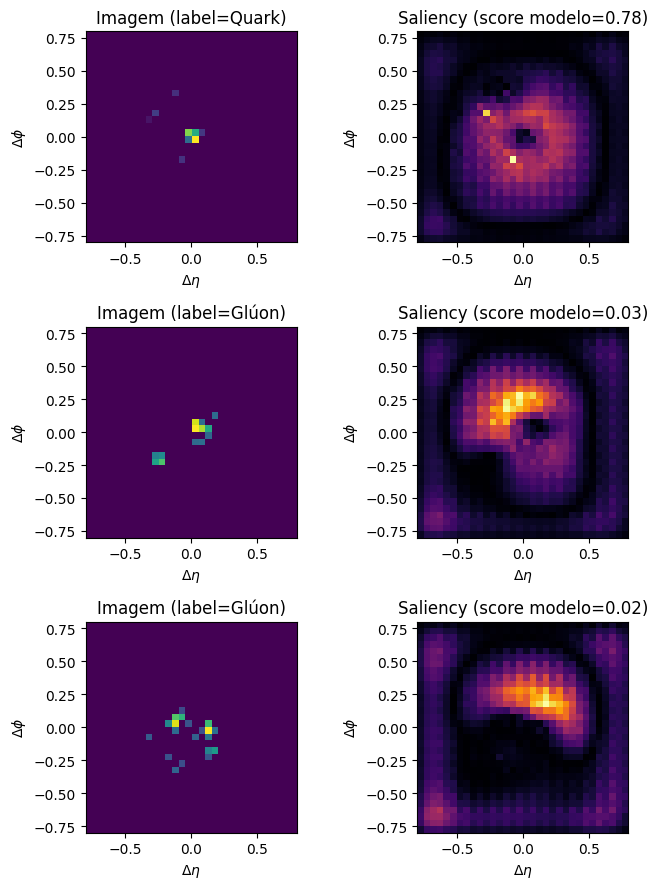

In [28]:
# monta datasets de teste (imagem) reaproveitando os arrays já processados
images_test_qg, _, _, labels_test_qg = qg_split["test"]
ds_test_qg_img = JetImageDataset(images_test_qg, labels_test_qg)
plot_saliency_examples(cnn_qg, ds_test_qg_img, labels_test_qg, class_names={0: "Glúon", 1: "Quark"})


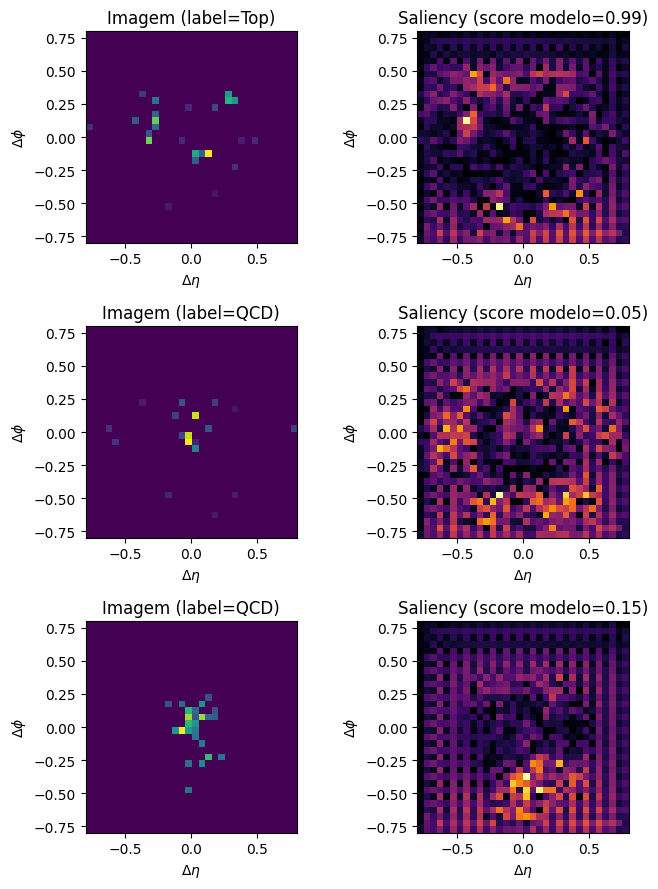

In [36]:
images_test_top, _, _, labels_test_top = top_split["test"]
ds_test_top_img = JetImageDataset(images_test_top, labels_test_top)
plot_saliency_examples(cnn_top, ds_test_top_img, labels_test_top, class_names={0: "QCD", 1: "Top"})


In [30]:
def plot_attention_examples(model, clouds, mask, labels, class_names, n_examples=3):
    fig, axes = plt.subplots(1, n_examples, figsize=(5 * n_examples, 5))
    idxs = np.random.choice(len(labels), n_examples, replace=False)
    x = torch.from_numpy(clouds[idxs]).float().to(DEVICE)
    m = torch.from_numpy(mask[idxs]).float().to(DEVICE)
    attn = model.get_cls_attention(x, m).cpu().numpy()  # (n_examples, N_part)

    # deta/dphi já estão embutidos nas features 1 e 2 de build_particle_cloud
    for i, ax in enumerate(np.atleast_1d(axes)):
        valid = mask[idxs[i]] > 0
        deta_ = clouds[idxs[i], valid, 1]
        dphi_ = clouds[idxs[i], valid, 2]
        weights = attn[i, valid]
        sizes = 50 + 2000 * (weights / (weights.max() + 1e-8))
        sc = ax.scatter(deta_, dphi_, s=sizes, c=weights, cmap="plasma", edgecolors="k", linewidths=0.5)
        ax.set_title(f"label={class_names[int(labels[idxs[i]])]}")
        ax.set_xlabel(r"$\Delta\eta$"); ax.set_ylabel(r"$\Delta\phi$")
        plt.colorbar(sc, ax=ax, fraction=0.046, label="peso de atenção do [CLS]")
    plt.tight_layout(); plt.show()


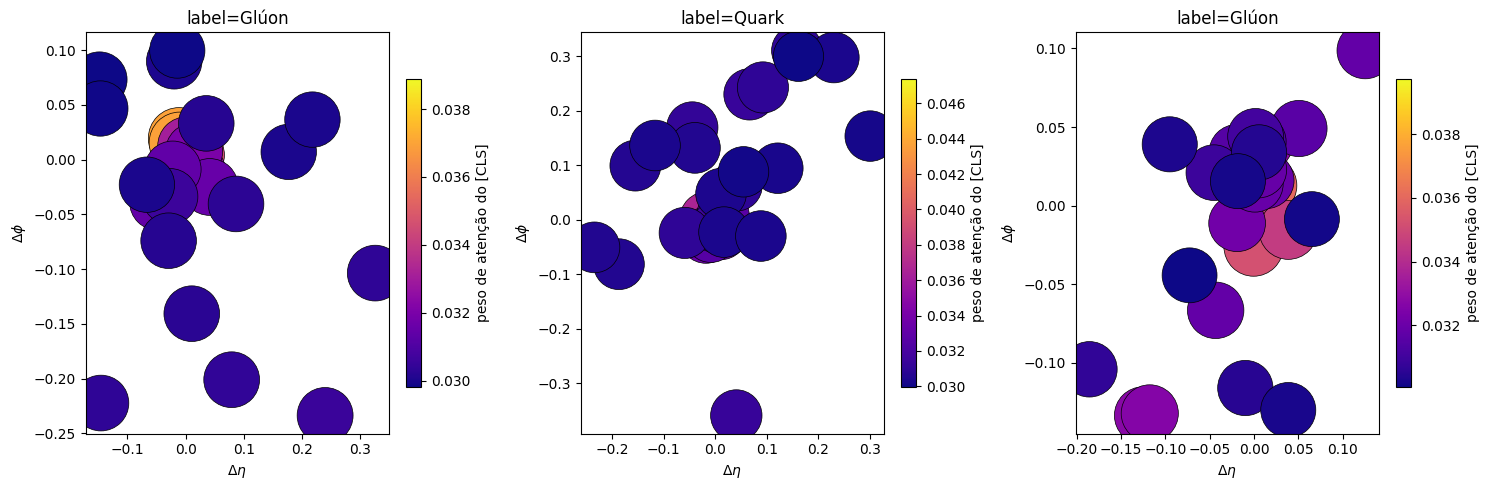

In [31]:
_, clouds_test_qg, mask_test_qg, labels_test_qg2 = qg_split["test"]
plot_attention_examples(part_qg, clouds_test_qg, mask_test_qg, labels_test_qg2,
                         class_names={0: "Glúon", 1: "Quark"})


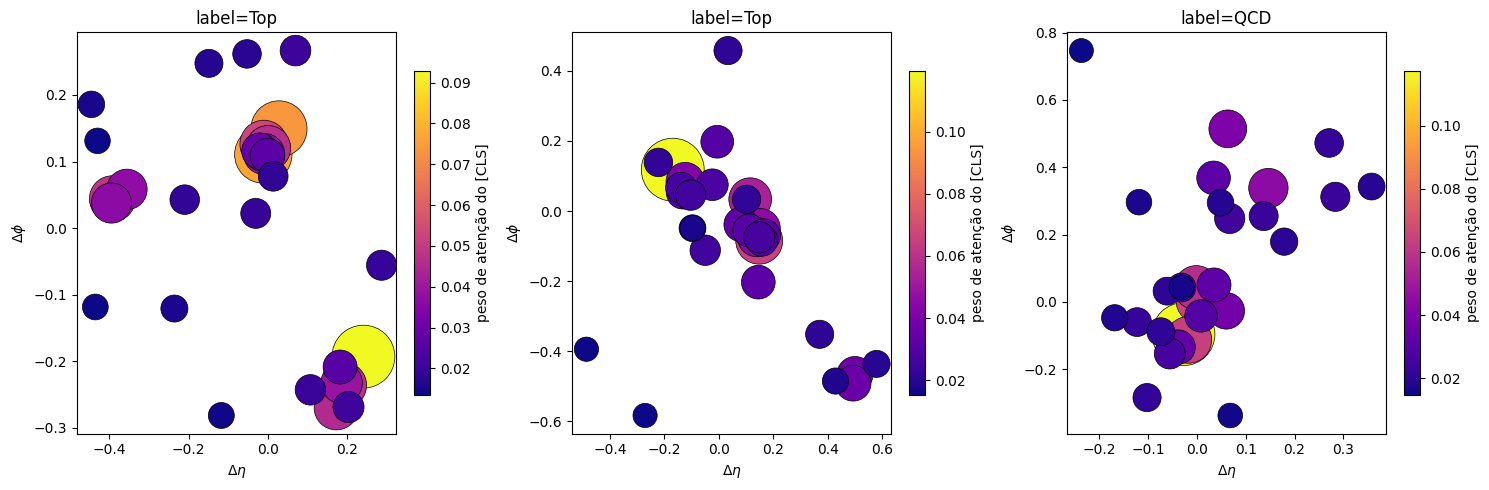

In [33]:
_, clouds_test_top, mask_test_top, labels_test_top2 = top_split["test"]
plot_attention_examples(part_top, clouds_test_top, mask_test_top, labels_test_top2,
                         class_names={0: "QCD", 1: "Top"})


In [44]:
def plot_attention_examples(model, clouds, mask, labels, class_names, n_examples=3):
    fig, axes = plt.subplots(1, n_examples, figsize=(5 * n_examples, 5))
    idxs = np.random.choice(len(labels), n_examples, replace=False)
    x = torch.from_numpy(clouds[idxs]).float().to(DEVICE)
    m = torch.from_numpy(mask[idxs]).float().to(DEVICE)
    attn = model.get_cls_attention(x, m).cpu().numpy()

    # calcula o score (probabilidade) do modelo pra cada jato
    with torch.no_grad():
        scores = torch.sigmoid(model(x, m)).cpu().numpy()

    for i, ax in enumerate(np.atleast_1d(axes)):
        valid = mask[idxs[i]] > 0
        deta_ = clouds[idxs[i], valid, 1]
        dphi_ = clouds[idxs[i], valid, 2]
        weights = attn[i, valid]
        sizes = 50 + 2000 * (weights / (weights.max() + 1e-8))
        sc = ax.scatter(deta_, dphi_, s=sizes, c=weights, cmap="plasma", edgecolors="k", linewidths=0.5)
        # título agora mostra label real E o score do modelo
        ax.set_title(f"label={class_names[int(labels[idxs[i]])]} | score modelo={scores[i]:.2f}")
        ax.set_xlabel(r"$\Delta\eta$"); ax.set_ylabel(r"$\Delta\phi$")
        plt.colorbar(sc, ax=ax, fraction=0.046, label="peso de atenção do [CLS]")
    plt.tight_layout(); plt.show()

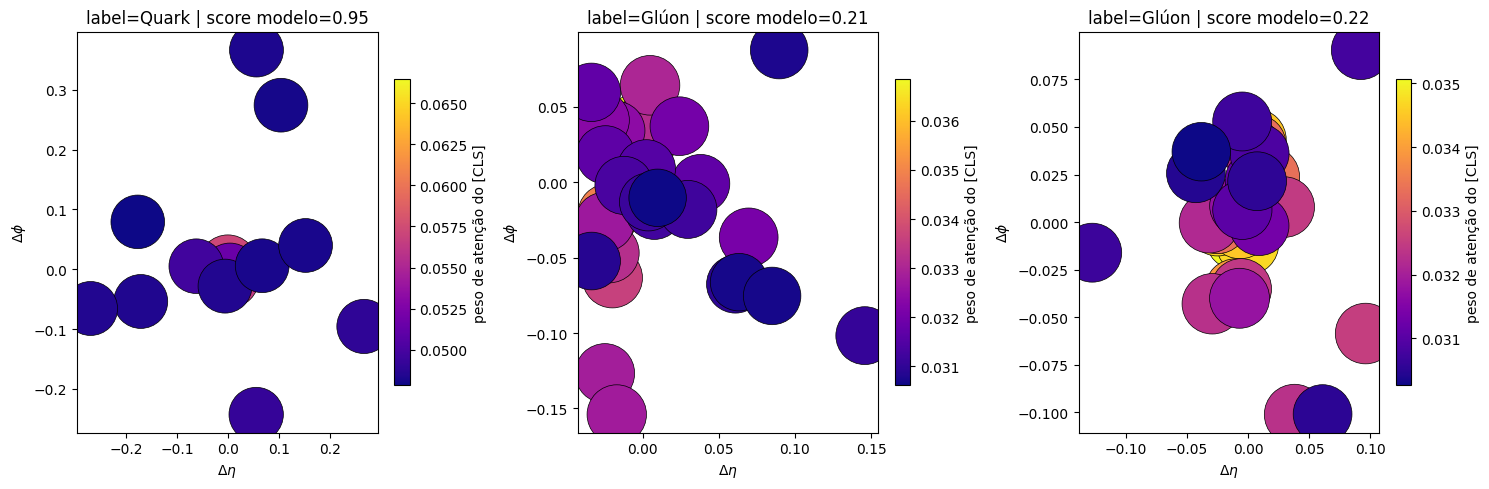

In [45]:
_, clouds_test_qg, mask_test_qg, labels_test_qg2 = qg_split["test"]
plot_attention_examples(part_qg, clouds_test_qg, mask_test_qg, labels_test_qg2,
                         class_names={0: "Glúon", 1: "Quark"})


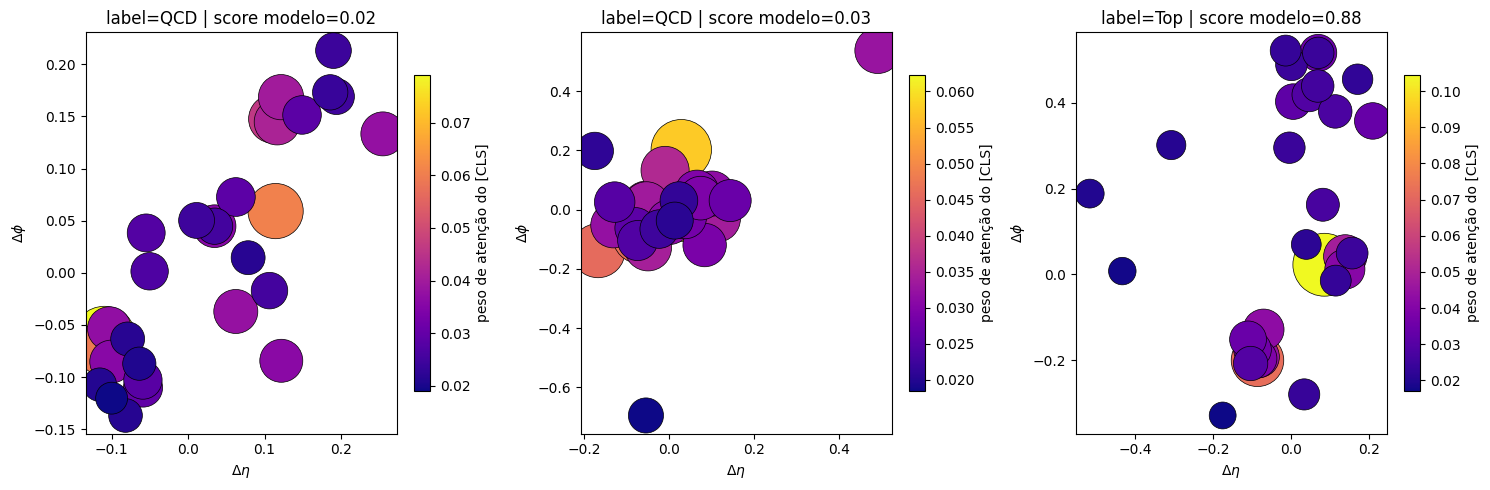

In [53]:
_, clouds_test_top, mask_test_top, labels_test_top2 = top_split["test"]
plot_attention_examples(part_top, clouds_test_top, mask_test_top, labels_test_top2,
                         class_names={0: "QCD", 1: "Top"})


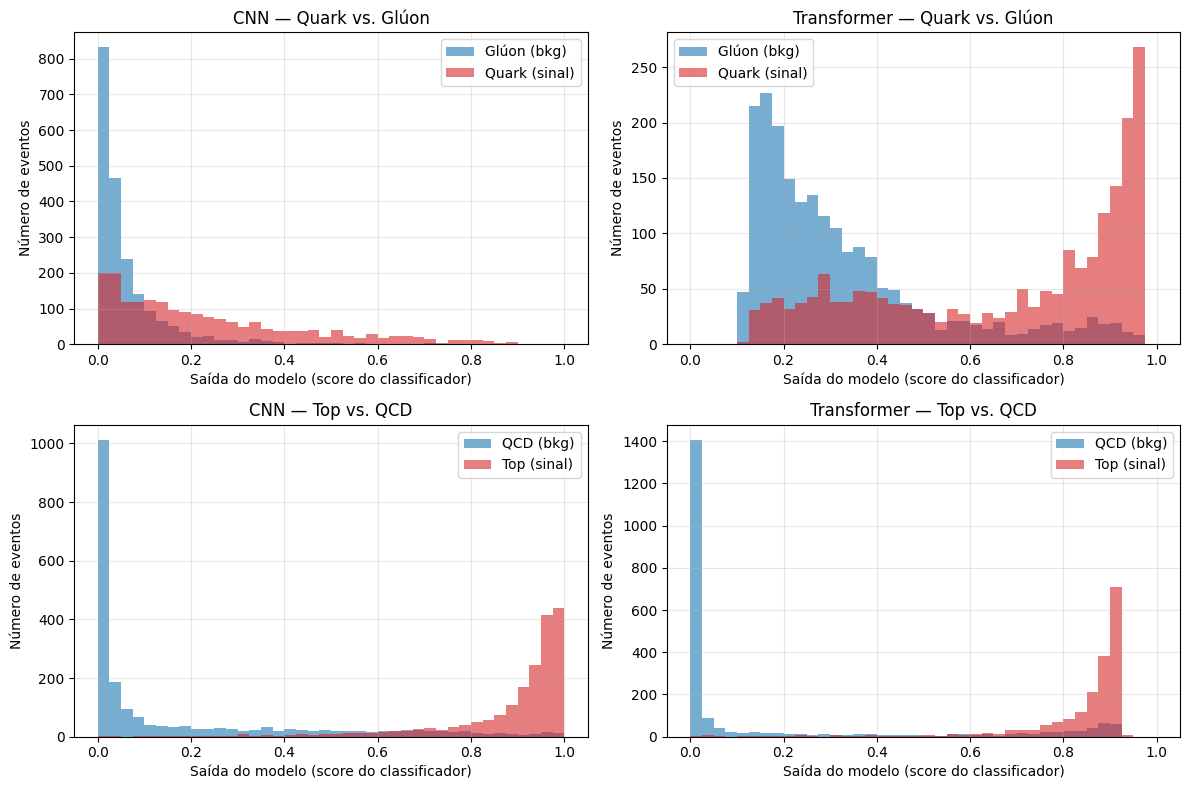

In [47]:
# Histogramas da saída do modelo (score) — sinal vs. background

def plot_score_histogram(ax, y_true, y_score, class_names, title, bins=40):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score).ravel()

    ax.hist(y_score[y_true == 0], bins=bins, range=(0, 1), alpha=0.6,
            label=class_names[0], color="tab:blue")
    ax.hist(y_score[y_true == 1], bins=bins, range=(0, 1), alpha=0.6,
            label=class_names[1], color="tab:red")

    ax.set_xlabel("Saída do modelo (score do classificador)")
    ax.set_ylabel("Número de eventos")
    # ax.set_yscale("log")  # remova ou adicione esta linha se preferir escala linear
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)


configs = [
    (cnn_qg,  img_loaders_qg["test"],   False, "CNN — Quark vs. Glúon",
     {0: "Glúon (bkg)", 1: "Quark (sinal)"}),
    (part_qg, cloud_loaders_qg["test"], True,  "Transformer — Quark vs. Glúon",
     {0: "Glúon (bkg)", 1: "Quark (sinal)"}),
    (cnn_top,  img_loaders_top["test"],   False, "CNN — Top vs. QCD",
     {0: "QCD (bkg)", 1: "Top (sinal)"}),
    (part_top, cloud_loaders_top["test"], True,  "Transformer — Top vs. QCD",
     {0: "QCD (bkg)", 1: "Top (sinal)"}),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (model, loader, is_cloud, title, class_names) in zip(axes.ravel(), configs):
    y_score, y_true = get_scores(model, loader, is_cloud)
    plot_score_histogram(ax, y_true, y_score, class_names, title)

plt.tight_layout()
plt.show()


**O que procurar nesses gráficos:**
- Nas *saliency maps* da CNN, espera-se que a rede dê mais peso à região central (onde está o "core" de alto pT do jato) e, no caso do top, também às regiões correspondentes aos sub-jatos secundários.
- Nos pesos de atenção do Transformer, partículas de **alto pT** e/ou que estão **espacialmente separadas do eixo principal** (candidatas a serem de um "prong" secundário, no caso do top) tendem a receber mais atenção do token `[CLS]`, isso é uma forma de o modelo aprender, sem supervisão explícita, a olhar para features de subestrutura de jato relevantes para a física.
- Os Histogramas mostram como os modelos estão classificando cada um dos jatos.


## 10. Conclusão

Neste notebook nós:

1. Pré-processamos dois datasets públicos de jatos (Quark/Glúon e Top/QCD) para uma representação comum de `(pT, Δη, Δφ)` por constituente, centrada no eixo do jato;
2. Construímos, a partir dela, tanto **imagens de calorímetro 2D** quanto **nuvens de partículas**;
3. Treinamos e comparamos uma **CNN estilo ResNet** e um **Particle-Transformer leve** (mecanismo de atenção que generaliza a ideia de uma GNN sobre a nuvem de partículas) nas duas tarefas;
4. Avaliamos com a métrica padrão da área (**AUC** e **rejeição de background a eficiência de sinal fixa**);
5. Interpretamos as decisões dos modelos com **saliency maps** (CNN) e **pesos de atenção** (Transformer).

### Extensões possíveis
- **Escala**: aumentar `N_TRAIN`/`EPOCHS`/tamanho das redes (idealmente com GPU) para se aproximar dos números de referência da literatura (AUC ~0.98+ na tarefa de top tagging com ParticleNet/ParT completos).
